# Test Accuracy Tables & Lyapunov Convergence Graphs

In [1]:
import os
os.environ.update(OMP_NUM_THREADS="1", OPENBLAS_NUM_THREADS="1", MKL_NUM_THREADS="1")
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning"

In [2]:
%load_ext autoreload
import sys, time, json, copy
import functools, warnings
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
import pandas as pd
import seaborn as sns
from pathlib import Path
from fastnanoid import generate
from datetime import datetime
from joblib import Parallel, delayed

In [3]:
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
lib_path = project_root / "lib"
sys.path.insert(0, str(lib_path))        
sys.path.insert(0, str(project_root))   

In [4]:
%autoreload 2
from lib.graph_factory import GraphFactory, add_graph_plot
from lib.proj_const_estimator import ProjConstEstimator
from lib.utils import fetch_dataset, get_alphas, rng, seed, save_to_pkl, load_from_pkl
from lib.classifier import ByzClassifier, load_run, save_run
from lib.system import SystemSimulator
from lib.metrics import MetricsCalculator
from lib.config import BASE_CONF, NUM_NODES
from lib.simulation import clf_stage, sim_task

**Experiment Configuration**

In [5]:
RUN_DIR = os.path.join(Path().resolve(), "dsgd_baseline")
os.makedirs(RUN_DIR, exist_ok=True)
IMAGES_DIR = os.path.join(RUN_DIR, "images")
GRAPHS = ['random-regular','watts-strogatz', 'geometric', 'erdos-renyi', 'barabasi-albert']
PERMUTED_GRAPHS = np.roll(np.asarray(GRAPHS),-1).tolist()
GRAPH_ABBREV = {
    'random-regular':'RR',
    'watts-strogatz':'WS', 
    'geometric':'RGG', 
    'erdos-renyi':'ER', 
    'barabasi-albert':'BA',
}
ATKS = ['label_flip']
ALGS = ['DSGD']
COLORS = dict(zip(ALGS, ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6']))
SEEDS = [111,333,777,888,222]
DEBUG = True

In [6]:
config = copy.deepcopy(BASE_CONF)

# Communication Graph
b = 8
config['graph_weights'] = 'MH_gen'
config['graph_args'] = {
    'ba_m': 5,
    'ws_k': 6,
    'ws_p': 0.1,
    'rand_reg_deg':10,
    'geom_radius':0.55,
    'er_p':min(1.0, 3.0 * np.log(NUM_NODES) / NUM_NODES),
}

# Stable Distribution
config['pi'] = (np.full(NUM_NODES, 1.0/NUM_NODES))
# config['pi-dir-alpha'] = 1
# pi = rng('dir','graphs').dirichlet(np.full(NUM_NODES,config['pi-dir-alpha']))
# config['pi'] = (pi / pi.sum())

# Classifier Training 
config['train']['b'] = b
config['train']['fpr_mean'] = 0.2
config['train']['fpr_spread'] = 0.05
config['train']['gamma_C'] = np.clip((config['train']['fpr_spread']*np.linspace(-1,1,NUM_NODES)) + config['train']['fpr_mean'], 0, 0.95)
config['oracle_params'] = [
    {'C_fnr':np.full(NUM_NODES, 0), 'C_fpr': np.full(NUM_NODES,0)},  # Perfect Oracle
    {'C_fnr':np.full(NUM_NODES, 1), 'C_fpr': np.full(NUM_NODES,0)},  # Threat Model IV Oracle
]

# System Simulation 
config['sys']['b'] = b
config['sys']['fpr_spread'] = 0.003
config['sys']['threat_model'] = 'T0'

# Miscellaneous
config['train']['clf_model'] = 'xgb'
config['data_heterogeneity'] = 100
config['reg_param'] = 1e-4
config['reg_param'] = 1
config['alpha_decay'] = (config['reg_param'] * config['alpha_init'])/2

In [7]:
CACHE = {}
for g_idx,g in enumerate(GRAPHS):
    cfg = copy.deepcopy(config)
    cfg['graph_type'] = g
    CACHE[g] = cfg

In [8]:
# Train Byzantine classifier in parallel over 5 topologies
res1 = Parallel(n_jobs=5, backend='loky', inner_max_num_threads=2, verbose=10)(
    delayed(clf_stage)(g, CACHE[g], RUN_DIR, b) for g in GRAPHS)
P1 = dict(res1)

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:  6.4min remaining:  9.7min
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:  7.6min remaining:  5.0min
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:  8.3min finished


In [9]:
jobs = [(g, atk, s) for g in GRAPHS for atk in ATKS for s in SEEDS]
res2 = Parallel(n_jobs=10, backend='loky', inner_max_num_threads=1, verbose=10)(
    delayed(sim_task)(g, CACHE[g], atk, s, P1[g]['proj_const'],
                      P1[g]['preproc'], P1[g]['est'], P1[g]['gamma_sys'],
                      dict(C_fpr=P1[g]['clf_thr']['fpr_ach'],
                           C_fnr=P1[g]['clf_thr']['fnr_ach'],
                           C_tau=P1[g]['clf_thr']['C_tau']),
                      ALGS, b, SEEDS)
    for g, atk, s in jobs)

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   5 tasks      | elapsed:   41.8s
[Parallel(n_jobs=10)]: Done   9 out of  25 | elapsed:   42.2s remaining:  1.2min
[Parallel(n_jobs=10)]: Done  12 out of  25 | elapsed:  1.3min remaining:  1.5min
[Parallel(n_jobs=10)]: Done  15 out of  25 | elapsed:  1.4min remaining:   55.9s
[Parallel(n_jobs=10)]: Done  18 out of  25 | elapsed:  1.4min remaining:   33.1s
[Parallel(n_jobs=10)]: Done  21 out of  25 | elapsed:  1.7min remaining:   20.0s
[Parallel(n_jobs=10)]: Done  25 out of  25 | elapsed:  1.8min finished


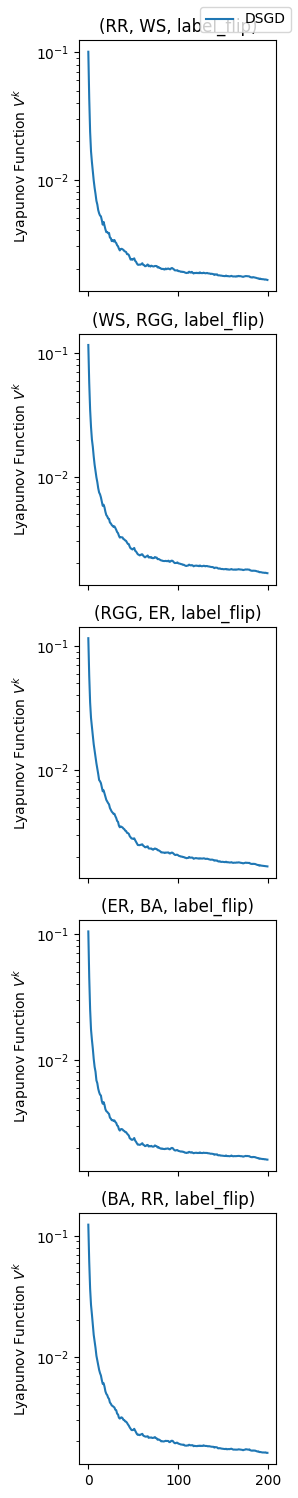

In [10]:
# Aggregate simulation results and save to disk
R = {(g, atk, s): (df, consts) for g, atk, s, df, consts in res2}
rows, met_rows, clf_rows = [], [], []
fig1, ax1 = plt.subplots(len(GRAPHS), len(ATKS),
                         figsize=(3 * len(ATKS), 3 * len(GRAPHS)),
                         squeeze=False, sharex=True)
all_parts = []
df_complete = pd.DataFrame()

for g_idx, g in enumerate(GRAPHS):
    ax = ax1[g_idx]
    clf_rows.append({'graph': g, 'proj_const': P1[g]['proj_const'],
                     **P1[g]['op_pt'], **P1[g]['metrics']})
    for atk_idx, atk in enumerate(ATKS):
        for s in SEEDS:
            df, consts = R[(g, atk, s)]
            first = (s == SEEDS[0])
            if first:
                df_reset = df.reset_index()
                df_reset['graph'] = g
                df_reset['attack'] = atk
                all_parts.append(df_reset)
                met_rows.append({**consts, 'atk': atk, 'graph': g})
            for alg in ALGS:
                col = 'test_acc_pi' if alg == 'RDSGD' else 'test_acc'
                rows.append({'alg': alg, 'atk': atk, 'seed': s,
                             'graph': g, 'test_acc': df.loc[alg, col].iloc[-1]})
                if first:
                    V = df.loc[alg, 'C_unif'] + np.pow(df.loc[alg, 'opt_gap'], 2)
                    if(atk_idx == 0): 
                        if(g_idx == len(GRAPHS)-1):
                            ax[atk_idx].plot(V, color=COLORS[alg], label=alg)
                            ax[atk_idx].set_xlabel='Iteration (k)'
                        else:
                            ax[atk_idx].plot(V, color=COLORS[alg])
                        ax[atk_idx].set_ylabel("Lyapunov Function $V^{k}$")
                    else: 
                        ax[atk_idx].plot(V, color=COLORS[alg])
                        ax[atk_idx].set_ylabel("")
                    ax[atk_idx].set(title=f'({GRAPH_ABBREV[g]}, {GRAPH_ABBREV[PERMUTED_GRAPHS[g_idx]]}, {atk})', yscale='log')

df_complete = pd.concat(all_parts, ignore_index=True).set_index(['graph', 'attack', 'alg', 'k'])
df_complete.to_csv(os.path.join(RUN_DIR, f'sys_sim.csv'))
                   
pd.DataFrame(clf_rows).set_index('graph').to_csv(os.path.join(RUN_DIR, f'clf_metrics.csv'))
pd.DataFrame(met_rows).set_index(['graph','atk']).to_csv(os.path.join(RUN_DIR, f'sys_metrics.csv'))

df_all = pd.DataFrame(rows)
df_summary = df_all.groupby(['graph','atk','alg'])['test_acc'].agg(['mean','std']).unstack('alg')
df_summary.to_csv(os.path.join(RUN_DIR, "test_accuracy.csv"))
                    
fig1.legend(loc="upper right")
fig1.tight_layout()
os.makedirs(IMAGES_DIR, exist_ok=True)
fig1.savefig(os.path.join(IMAGES_DIR, f'conv_plots.png'))

In [11]:
df_tmp = df_summary['mean'].drop(columns=['ORACLE_0','ORACLE_1'])
filt = df_tmp.max(axis=1) == df_tmp['RDSGD']
display(df_tmp[~filt])

KeyError: "['ORACLE_0', 'ORACLE_1'] not found in axis"

In [ ]:
df2 = df_tmp[~filt]
df_cmp = (df2.T - df2.max(axis=1).to_numpy()).T
df_cmp

In [ ]:
# Save experiment configuration
payload = copy.deepcopy(config)
del payload['train']['gamma_C']
del payload['pi']
del payload['oracle_params']
with open(os.path.join(RUN_DIR, f'config.json'), 'w') as f:
    def convert(o):
        if isinstance(o, np.generic):
            return o.item()
        raise TypeError(f'{type(o)} not serializable')
    json.dump(payload, f, indent=2, default=convert)